# Neural Network Model

This notebook builds and evaluates our neural network model for classifying which social media platform a post belongs to.

## Goals 

This notebook follows the same split and feature policy as the earlier modeling notebooks:
- Use the saved train/validation/test parquet files from `create_datasets.ipynb`.
- Use only text-derived information.
- Exclude IDs, dates, authors, and platform-specific metadata that could leak platform identity in an unhelpful way.

## Model design

The neural network uses:

1. Sentence embeddings from `sentence-transformers/all-MiniLM-L6-v2`.
2. Engineered text statistics such as length, number of hashtags, mentions, URLs, all-caps words, etc.
3. A small MLP classifier trained with cross-entropy loss.

## Why a neural network?

This is our most flexible supervised model. The neural network keeps the same text-only feature policy as the earlier notebooks, but it can jointly learn from dense sentence embeddings and engineered text statistics in a way that a linear model cannot. We include it because it gives the project a stronger nonlinear alternative to both the sparse logistic-regression baseline and the tree-based XGBoost model.

The main risk is overfitting. To control that, we keep the network small, use dropout and batch normalization, and rely on validation loss with early stopping instead of training for a fixed large number of epochs.

In [21]:
%pip install polars pyarrow pandas matplotlib scikit-learn scipy torch sentence-transformers joblib



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
from pathlib import Path
from time import perf_counter
import random
import json
import re

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import joblib

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)


polars.config.Config

## Reproducibility

In [23]:
# set up seeds and determinism for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA device: NVIDIA GeForce RTX 4070 Laptop GPU


## Paths

In [24]:
# Set up the input and output paths for the notebook
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "train_210k.parquet"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "val_45k.parquet"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "test_45k.parquet"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NN_OUTPUT_DIR = MODEL_OUTPUT_DIR / "neural_network"
NN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_CACHE_DIR = NN_OUTPUT_DIR / "embedding_cache"
EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH, TRAIN_PATH.exists())
print(VAL_PATH, VAL_PATH.exists())
print(TEST_PATH, TEST_PATH.exists())
print("Outputs will be saved to:", NN_OUTPUT_DIR)


/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/train_210k.parquet True
/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/val_45k.parquet True
/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/test_45k.parquet True
Outputs will be saved to: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network


## Load train, validation, and test data

In [25]:
train_df = pl.read_parquet(TRAIN_PATH)
val_df = pl.read_parquet(VAL_PATH)
test_df = pl.read_parquet(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (209987, 18)
Validation: (44997, 18)
Test: (44998, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],f64,f64,…,i8,str,f64,str,f64,f64,str
"""hackernews""","""34593357""","""TheCowboy""","""The idea that tendencies for e…",2023-01-31 05:07:08,null,null,…,1,"""2023-01""",0.0,null,null,null,"""34592394"""
"""hackernews""","""45704131""","""senordevnyc""","""The actual quote is “make some…",2025-10-25 10:21:45,null,null,…,10,"""2025-10""",0.0,null,null,null,"""45704110"""
"""hackernews""","""41076936""","""enriquto""","""> the way it was made callable…",2024-07-26 04:48:48,null,null,…,7,"""2024-07""",0.0,null,null,null,"""41074451"""
"""reddit""","""t3_1fzrjm3""","""sanaloyuncu""","""Hangisini izlemeliyim? Edebiya…",2024-10-09 00:00:00,null,null,…,10,"""2024-10""",1.0,"""liseliler""",1.0,1.0,null
"""hackernews""","""47058341""","""robinwhg""","""But there already is cheaper c…",2026-02-18 02:40:55,null,null,…,2,"""2026-02""",0.0,null,null,null,"""47056458"""


## Quick data check

The dataset was designed to be balanced across the three platforms, so accuracy is a reasonable headline metric. We will still use the full classification report and confusion matrix so we do not rely only on accuracy.

In [26]:
print("Train class counts")
print(train_df.group_by("platform").len().sort("platform"))

print("\nValidation class counts")
print(val_df.group_by("platform").len().sort("platform"))

print("\nTest class counts")
print(test_df.group_by("platform").len().sort("platform"))

Train class counts
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 69988 │
│ reddit     ┆ 69999 │
│ twitter    ┆ 70000 │
└────────────┴───────┘

Validation class counts
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 14997 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘

Test class counts
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 14998 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘


## Add text statistics

Similar to the other models, we again intentionally only use text-derived features.
We reuse the same extra text statistic feature engineering from the logistic regression baseline notebook to create additional features.

In [27]:
def add_text_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col("text").str.count_matches(r"\?").alias("num_questions"),
        pl.col("text").str.count_matches(r"!").alias("num_exclamations"),
        pl.col("text").str.count_matches(r"#\w+").alias("num_hashtags"),
        pl.col("text").str.count_matches(r"@\w+").alias("num_mentions"),
        pl.col("text").str.count_matches(r"http[s]?://").alias("num_urls"),
        pl.col("text").str.count_matches(r"\d").alias("num_digits"),
        pl.col("text").str.count_matches(r"\b[A-Z]{2,}\b").alias("num_allcaps_words"),
        pl.col("text").str.count_matches(r"\b\w+\b").alias("num_words"),
    ]).with_columns([
        (
            pl.col("text_len") /
            pl.when(pl.col("num_words") > 0).then(pl.col("num_words")).otherwise(1)
        ).alias("avg_word_len"),
    ])

train_df = add_text_stats(train_df)
val_df = add_text_stats(val_df)
test_df = add_text_stats(test_df)

TEXT_STAT_COLS = [
    "text_len",
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "num_digits",
    "num_allcaps_words",
    "num_words",
    "avg_word_len",
]

train_df.select(["platform", "text"] + TEXT_STAT_COLS).head()

platform,text,text_len,num_questions,num_exclamations,num_hashtags,num_mentions,num_urls,num_digits,num_allcaps_words,num_words,avg_word_len
str,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64
"""hackernews""","""The idea that tendencies for e…",290,0,0,0,0,0,0,0,49,5.918367
"""hackernews""","""The actual quote is “make some…",77,0,0,0,0,0,0,0,13,5.923077
"""hackernews""","""> the way it was made callable…",692,1,0,0,0,1,3,0,122,5.672131
"""reddit""","""Hangisini izlemeliyim? Edebiya…",259,2,0,0,0,0,2,0,35,7.4
"""hackernews""","""But there already is cheaper c…",113,1,0,0,0,0,1,0,19,5.947368


## Convert to pandas / NumPy inputs

In [28]:
train_pdf = train_df.to_pandas()
val_pdf = val_df.to_pandas()
test_pdf = test_df.to_pandas()

X_train_text = train_pdf["text"].astype(str)
X_val_text = val_pdf["text"].astype(str)
X_test_text = test_pdf["text"].astype(str)

X_train_num = train_pdf[TEXT_STAT_COLS].astype(float)
X_val_num = val_pdf[TEXT_STAT_COLS].astype(float)
X_test_num = test_pdf[TEXT_STAT_COLS].astype(float)

y_train = train_pdf["platform"].astype(str)
y_val = val_pdf["platform"].astype(str)
y_test = test_pdf["platform"].astype(str)

print("Train examples:", len(X_train_text))
print("Validation examples:", len(X_val_text))
print("Test examples:", len(X_test_text))

Train examples: 209987
Validation examples: 44997
Test examples: 44998


## Build sentence-embedding + text-stat neural-network features

Instead of feeding the neural network TF-IDF features, we encode each post with `all-MiniLM-L6-v2` sentence embeddings similar to the xgboost model to better capture semantic and stylistic similarity along witht he engineered text statistics created earlier.

In [29]:
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_BATCH_SIZE = 256
EMBEDDING_DEVICE = device.type
NORMALIZE_EMBEDDINGS = True

print("Embedding device:", EMBEDDING_DEVICE)

def encode_or_load_embeddings(texts, split_name: str) -> np.ndarray:
    """Encode text with MiniLM, caching embeddings so reruns are much faster."""
    cache_suffix = "full"
    cache_path = EMBEDDING_CACHE_DIR / f"{split_name}_minilm_l6_v2_{cache_suffix}.npy"

    if cache_path.exists():
        print(f"Loading cached {split_name} embeddings from {cache_path}")
        return np.load(cache_path)

    print(f"Encoding {split_name} text with {EMBEDDING_MODEL_NAME}...")
    t0 = perf_counter()

    embeddings = embedding_model.encode(
        texts,
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=NORMALIZE_EMBEDDINGS,
    ).astype(np.float32)

    t1 = perf_counter()
    print(f"{split_name} embedding shape: {embeddings.shape}")
    print(f"{split_name} encoding time: {t1 - t0:.2f} seconds")

    np.save(cache_path, embeddings)
    print(f"Saved {split_name} embeddings to {cache_path}")

    return embeddings


print("Loading sentence embedding model...")
t0 = perf_counter()
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=EMBEDDING_DEVICE)
t1 = perf_counter()

print(f"Embedding model loaded in {t1 - t0:.2f} seconds")
print("Embedding model device:", embedding_model.device)

X_train_embed = encode_or_load_embeddings(X_train_text.tolist(), "train")
X_val_embed = encode_or_load_embeddings(X_val_text.tolist(), "val")
X_test_embed = encode_or_load_embeddings(X_test_text.tolist(), "test")

print("Embedding shapes:")
print(X_train_embed.shape, X_val_embed.shape, X_test_embed.shape)


Embedding device: cuda
Loading sentence embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded in 2.15 seconds
Embedding model device: cuda:0
Loading cached train embeddings from /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network/embedding_cache/train_minilm_l6_v2_full.npy
Loading cached val embeddings from /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network/embedding_cache/val_minilm_l6_v2_full.npy
Loading cached test embeddings from /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network/embedding_cache/test_minilm_l6_v2_full.npy
Embedding shapes:
(209987, 384) (44997, 384) (44998, 384)


In [30]:
print("Scaling text-stat features")
num_scaler = StandardScaler()

X_train_num_scaled = num_scaler.fit_transform(X_train_num).astype(np.float32)
X_val_num_scaled = num_scaler.transform(X_val_num).astype(np.float32)
X_test_num_scaled = num_scaler.transform(X_test_num).astype(np.float32)

# Additionally use standard scaling 
print("Scaling embedding features")
embedding_scaler = StandardScaler()

X_train_embed_scaled = embedding_scaler.fit_transform(X_train_embed).astype(np.float32)
X_val_embed_scaled = embedding_scaler.transform(X_val_embed).astype(np.float32)
X_test_embed_scaled = embedding_scaler.transform(X_test_embed).astype(np.float32)

X_train_final = np.hstack([X_train_embed_scaled, X_train_num_scaled]).astype(np.float32)
X_val_final = np.hstack([X_val_embed_scaled, X_val_num_scaled]).astype(np.float32)
X_test_final = np.hstack([X_test_embed_scaled, X_test_num_scaled]).astype(np.float32)

print("Final dense feature shapes:")
print(X_train_final.shape, X_val_final.shape, X_test_final.shape)


Scaling text-stat features
Scaling embedding features
Final dense feature shapes:
(209987, 394) (44997, 394) (44998, 394)


## Encode labels

In [31]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train).astype(np.int64)
y_val_encoded = label_encoder.transform(y_val).astype(np.int64)
y_test_encoded = label_encoder.transform(y_test).astype(np.int64)

print("Classes:", list(label_encoder.classes_))
print("Encoded labels:", sorted(set(y_train_encoded)))

Classes: ['hackernews', 'reddit', 'twitter']
Encoded labels: [np.int64(0), np.int64(1), np.int64(2)]


## Set up dataloader

In [32]:
class PlatformDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(
    PlatformDataset(X_train_final, y_train_encoded),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    PlatformDataset(X_val_final, y_val_encoded),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    PlatformDataset(X_test_final, y_test_encoded),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

## Define our nueral network

This is intentionally a small MLP:

- Input: MiniLM sentence embedding features + engineered text stats.
- Hidden layers: two fully connected layers.
- Batch normalization and dropout: help stabilize training and reduce overfitting.
- Output: one logit per platform.


In [33]:
class PlatformMLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden_dim: int = 256, dropout: float = 0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_final.shape[1]
num_classes = len(label_encoder.classes_)

print("Input dim:", input_dim)
print("Number of classes:", num_classes)

Input dim: 394
Number of classes: 3


## Training helpers

In [34]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    all_preds = []
    all_true = []

    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)

            batch_size = y_batch.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (preds == y_batch).sum().item()
            total_examples += batch_size

            all_preds.append(preds.detach().cpu().numpy())
            all_true.append(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)

    return avg_loss, accuracy, all_true, all_preds

## Train with early stopping

We first run a very small hyperparameter sweep on the validation set, then retrain a final model with the best settings.

In [42]:
NN_SWEEP_CONFIGS = [
    {"hidden_dim": 256, "dropout": 0.30, "learning_rate": 1e-3, "weight_decay": 1e-4},
    {"hidden_dim": 128, "dropout": 0.30, "learning_rate": 1e-3, "weight_decay": 1e-4},
    {"hidden_dim": 64, "dropout": 0.30, "learning_rate": 1e-3, "weight_decay": 1e-4},
]

def train_mlp_config(config: dict, epochs: int, patience: int, verbose: bool = True):
    model = PlatformMLP(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None
    best_val_true = None
    best_val_pred = None
    best_val_acc = None
    epochs_without_improvement = 0
    history = []

    t0_total = perf_counter()
    for epoch in range(1, epochs + 1):
        t0 = perf_counter()
        train_loss, train_acc, _, _ = run_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_true_epoch, val_pred_epoch = run_one_epoch(model, val_loader, criterion)
        t1 = perf_counter()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "seconds": t1 - t0,
        })

        if verbose:
            print(
                f"Epoch {epoch:02d} | "
                f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
                f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
                f"{t1 - t0:.2f}s"
            )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_true = val_true_epoch
            best_val_pred = val_pred_epoch
            best_val_acc = val_acc
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                if verbose:
                    print(f"Early stopping after epoch {epoch}. Best epoch: {best_epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    val_true_labels = label_encoder.inverse_transform(best_val_true)
    val_pred_labels = label_encoder.inverse_transform(best_val_pred)
    val_report = classification_report(val_true_labels, val_pred_labels, output_dict=True)

    return {
        "model": model,
        "criterion": criterion,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_acc,
        "best_val_macro_f1": float(val_report["macro avg"]["f1-score"]),
        "training_seconds": perf_counter() - t0_total,
    }

nn_sweep_results = []
for config in NN_SWEEP_CONFIGS:
    print(f"Trying neural-network config: {config}")
    sweep_result = train_mlp_config(config, epochs=10, patience=2, verbose=False)
    nn_sweep_results.append({
        **config,
        "best_epoch": sweep_result["best_epoch"],
        "val_loss": float(sweep_result["best_val_loss"]),
        "val_accuracy": float(sweep_result["best_val_accuracy"]),
        "val_macro_f1": float(sweep_result["best_val_macro_f1"]),
        "training_seconds": float(sweep_result["training_seconds"]),
    })

nn_sweep_df = pd.DataFrame(nn_sweep_results).sort_values(["val_macro_f1", "val_accuracy"], ascending=False)
print("Neural-network sweep results:")
print(nn_sweep_df)

best_row = nn_sweep_df.iloc[0]
BEST_NN_CONFIG = {
    "hidden_dim": int(best_row["hidden_dim"]),
    "dropout": float(best_row["dropout"]),
    "learning_rate": float(best_row["learning_rate"]),
    "weight_decay": float(best_row["weight_decay"]),
}
print("\nBest neural-network config:", BEST_NN_CONFIG)

Trying neural-network config: {'hidden_dim': 256, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Trying neural-network config: {'hidden_dim': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Trying neural-network config: {'hidden_dim': 64, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Neural-network sweep results:
   hidden_dim  dropout  learning_rate  weight_decay  best_epoch  val_loss  \
0         256      0.3          0.001        0.0001           8  0.165629   
1         128      0.3          0.001        0.0001           9  0.168831   
2          64      0.3          0.001        0.0001           9  0.177424   

   val_accuracy  val_macro_f1  training_seconds  
0      0.941263      0.941320         16.371807  
1      0.939507      0.939573         15.235044  
2      0.936551      0.936646         15.827247  

Best neural-network config: {'hidden_dim': 256, 'dropout': 0.3, 'learning_rate': 0.001, 'weight_decay': 0.0001}


In [43]:
EPOCHS = 25
PATIENCE = 4

final_result = train_mlp_config(BEST_NN_CONFIG, epochs=EPOCHS, patience=PATIENCE, verbose=True)
model = final_result["model"]
criterion = final_result["criterion"]
history = final_result["history"]
best_epoch = final_result["best_epoch"]
best_val_loss = final_result["best_val_loss"]
LEARNING_RATE = BEST_NN_CONFIG["learning_rate"]
WEIGHT_DECAY = BEST_NN_CONFIG["weight_decay"]

print(f"Total training time: {final_result['training_seconds']:.2f} seconds")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 01 | train loss 0.2932 acc 0.8902 | val loss 0.2080 acc 0.9241 | 1.65s
Epoch 02 | train loss 0.2108 acc 0.9229 | val loss 0.1914 acc 0.9315 | 1.94s
Epoch 03 | train loss 0.1894 acc 0.9312 | val loss 0.1772 acc 0.9351 | 1.79s
Epoch 04 | train loss 0.1756 acc 0.9368 | val loss 0.1708 acc 0.9395 | 1.82s
Epoch 05 | train loss 0.1661 acc 0.9399 | val loss 0.1687 acc 0.9396 | 1.15s
Epoch 06 | train loss 0.1583 acc 0.9428 | val loss 0.1669 acc 0.9400 | 1.22s
Epoch 07 | train loss 0.1528 acc 0.9449 | val loss 0.1665 acc 0.9403 | 1.72s
Epoch 08 | train loss 0.1455 acc 0.9475 | val loss 0.1644 acc 0.9417 | 1.71s
Epoch 09 | train loss 0.1417 acc 0.9485 | val loss 0.1636 acc 0.9410 | 2.20s
Epoch 10 | train loss 0.1366 acc 0.9503 | val loss 0.1630 acc 0.9425 | 2.32s
Epoch 11 | train loss 0.1303 acc 0.9527 | val loss 0.1652 acc 0.9420 | 1.99s
Epoch 12 | train loss 0.1292 acc 0.9532 | val loss 0.1672 acc 0.9416 | 1.45s
Epoch 13 | train loss 0.1240 acc 0.9549 | val loss 0.1667 acc 0.9424 | 1.49s

The small sweep above is not meant to exhaustively optimize the architecture. Instead, it checks whether a few nearby choices for hidden width, dropout, learning rate, and weight decay materially change validation performance. We then keep the best validation configuration and retrain one final model under the same early-stopping rule so the final test evaluation reflects the tuned setup rather than one of the short sweep runs.

## Plot training curves

## Difficulty concepts used in modeling

This project’s modeling section most clearly demonstrates three higher-difficulty concepts from the rubric. First, we use **feature engineering** through text statistics such as question counts, mention counts, URL counts, word counts, and average word length, then combine those with learned text representations. Second, we use **hyperparameter tuning** in a disciplined way across all three models: logistic regression, XGBoost, and the neural network each run a validation-based sweep before the final training pass. Third, we use **feature importance / model interpretation** in two different ways depending on the model family: the logistic baseline uses readable coefficients on words and text statistics, while the XGBoost embedding model is interpreted through high-value and low-value example posts for the most important latent dimensions.

These concepts are not included just for breadth. They directly support the project conclusion: engineered text features remain useful even when stronger models are added, tuned nonlinear models improve performance over the simple baseline, and the interpretation sections help explain what kinds of platform-specific language patterns each model is learning rather than only reporting accuracy.

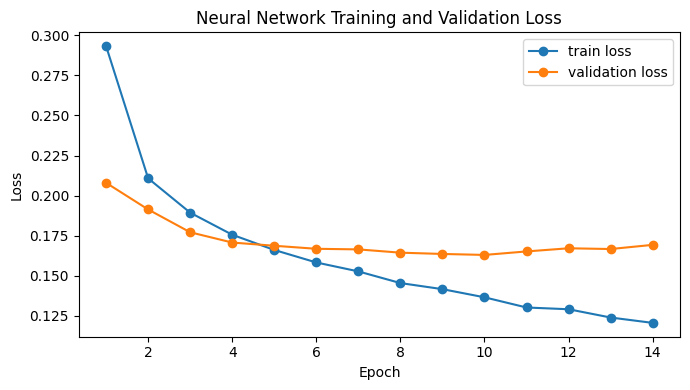

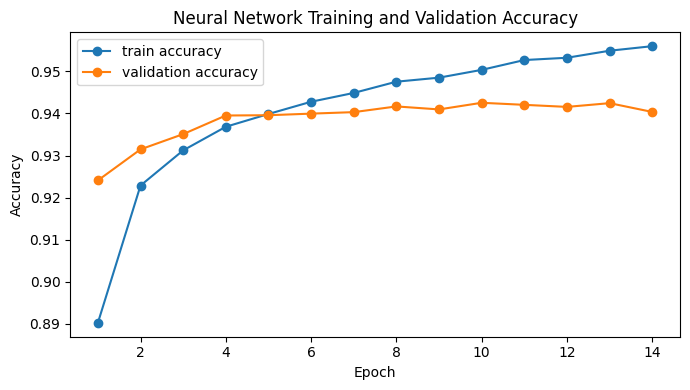

In [44]:
history_df = pd.DataFrame(history)
history_df.to_csv(NN_OUTPUT_DIR / "nn_training_history.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(NN_OUTPUT_DIR / "nn_loss_curve.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="train accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(NN_OUTPUT_DIR / "nn_accuracy_curve.png", dpi=150)
plt.show()

## Validation evaluation

In [45]:
val_loss, val_accuracy, val_true_encoded, val_pred_encoded = run_one_epoch(model, val_loader, criterion)

val_true = label_encoder.inverse_transform(val_true_encoded)
val_pred = label_encoder.inverse_transform(val_pred_encoded)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_accuracy)
print(classification_report(val_true, val_pred))

Validation loss: 0.16303409025462826
Validation accuracy: 0.9425295019667977
              precision    recall  f1-score   support

  hackernews       0.93      0.95      0.94     14997
      reddit       0.94      0.94      0.94     15000
     twitter       0.96      0.94      0.95     15000

    accuracy                           0.94     44997
   macro avg       0.94      0.94      0.94     44997
weighted avg       0.94      0.94      0.94     44997



## Test evaluation

With finalized hyperparameters

In [46]:
test_loss, test_accuracy, test_true_encoded, test_pred_encoded = run_one_epoch(model, test_loader, criterion)

test_true = label_encoder.inverse_transform(test_true_encoded)
test_pred = label_encoder.inverse_transform(test_pred_encoded)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print(classification_report(test_true, test_pred))

Test loss: 0.1608619904011068
Test accuracy: 0.9436641628516823
              precision    recall  f1-score   support

  hackernews       0.93      0.95      0.94     14998
      reddit       0.94      0.94      0.94     15000
     twitter       0.96      0.94      0.95     15000

    accuracy                           0.94     44998
   macro avg       0.94      0.94      0.94     44998
weighted avg       0.94      0.94      0.94     44998



## Confusion matrix

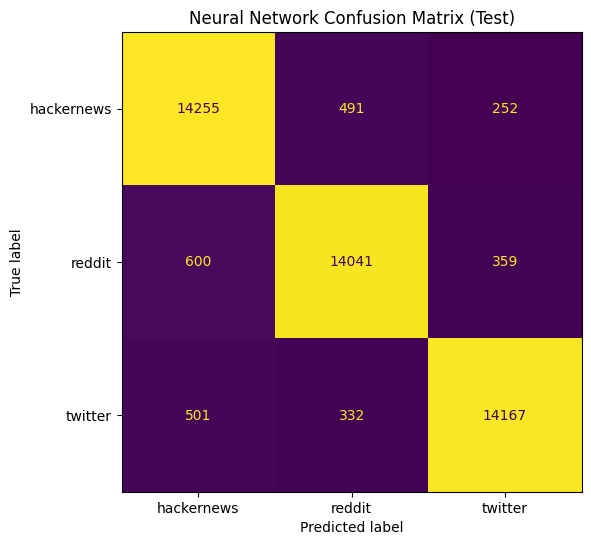

In [47]:
labels = list(label_encoder.classes_)

cm = confusion_matrix(test_true, test_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Neural Network Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(NN_OUTPUT_DIR / "nn_confusion_matrix.png", dpi=150)
plt.show()

## Save model and preprocessing artifacts

Save some file sor the dashboard. The full prediction pipeline needs the sentence embedding model name, embedding scaler, text-stat scaler, label encoder, and PyTorch model weights.

In [48]:
model_path = NN_OUTPUT_DIR / "platform_mlp_state_dict.pt"
torch.save(model.state_dict(), model_path)

preprocessing_bundle = {
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "normalize_embeddings": NORMALIZE_EMBEDDINGS,
    "embedding_scaler": embedding_scaler,
    "num_scaler": num_scaler,
    "label_encoder": label_encoder,
    "text_stat_cols": TEXT_STAT_COLS,
    "input_dim": input_dim,
    "num_classes": num_classes,
    "hidden_dim": BEST_NN_CONFIG["hidden_dim"],
    "dropout": BEST_NN_CONFIG["dropout"],
}

bundle_path = NN_OUTPUT_DIR / "platform_mlp_embedding_preprocessing.joblib"
joblib.dump(preprocessing_bundle, bundle_path)

metrics = {
    "model_type": "MiniLM sentence embeddings + text stats + PyTorch MLP",
    "embedding_model_name": EMBEDDING_MODEL_NAME,
    "normalize_embeddings": bool(NORMALIZE_EMBEDDINGS),
    "tuning_results": nn_sweep_results,
    "best_config": BEST_NN_CONFIG,
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "validation_loss": float(val_loss),
    "validation_accuracy": float(val_accuracy),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "classes": list(label_encoder.classes_),
    "embedding_dim": int(X_train_embed.shape[1]),
    "num_text_stat_features": int(len(TEXT_STAT_COLS)),
    "input_dim": int(input_dim),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),
    "weight_decay": float(WEIGHT_DECAY),
}

metrics_path = NN_OUTPUT_DIR / "nn_embedding_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved model to:", model_path)
print("Saved preprocessing bundle to:", bundle_path)
print("Saved metrics to:", metrics_path)


Saved model to: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network/platform_mlp_state_dict.pt
Saved preprocessing bundle to: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network/platform_mlp_embedding_preprocessing.joblib
Saved metrics to: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/neural_network/nn_embedding_metrics.json
